# Tick-constrained books / undercutting

**Deck:** Rindi et al. MMCV #3 Paris 2014 — tick-constrained books (spread ≤ 1–2 ticks) activate the undercutting channel when relative tick falls (slides ~pp. 20–25).

**Slice:** ETH · Hyperliquid + Deribit + Kraken · UTC days from `out/pass1/panel.json`.
**Honest TOB labels:** Kraken rows with `warehouse:trade_synth` are flagged `is_synth` and excluded from OFI / quote-level flip event studies.

Artifacts: `out/tick_constraint/` · regenerate via `chapters/tick_constraint/_run_local.py`.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from IPython.display import Image, display, Markdown

OUT = Path('../../out/tick_constraint').resolve()
FIGS = OUT / 'figs'
summary = json.loads((OUT / 'summary.json').read_text())
df = pd.DataFrame(summary['rows'])
print('symbol', summary['symbol'], 'days', summary['days'])
print('tob_ok', summary['n_tob_ok'], 'synth', summary['n_synth'])
print('median frac_constrained_2tick', round(summary['median_frac_c'], 4))
print('median undercut_rate', round(summary['median_undercut'], 4))
print('desk_label_counts', summary['desk_label_counts'])
print('note:', summary.get('note_kraken'))
cols = ['venue','day','is_synth','frac_constrained_2tick','undercut_rate','ofi_corr','markout_1s_bps','n_flips_relax','desk_label','tob_source']
display(df[cols].sort_values(['day','venue']))

symbol ETH days ['2026-09-26', '2026-09-27', '2026-09-30']
tob_ok 9 synth 3
median frac_constrained_2tick 0.0971
median undercut_rate 0.0612
desk_label_counts {'constrained_quiet': 3, 'n/a_synth_tob': 3, 'unconstrained': 3}
note: Kraken TOB often warehouse:trade_synth — labeled is_synth; excluded from OFI event study


,venue,day,is_synth,frac_constrained_2tick,undercut_rate,ofi_corr,markout_1s_bps,n_flips_relax,desk_label,tob_source
1,deribit,2026-09-26,False,0.097090,0.049432,-0.008851,-29.279517,420,unconstrained,warehouse:l2_tob/s3_cache
0,hyperliquid,2026-09-26,False,0.997365,0.041722,0.644263,1.042512,35,constrained_quiet,warehouse:l2_rebuild/s3_cache
2,kraken,2026-09-26,True,0.000000,0.357343,NaN,2.358556,0,n/a_synth_tob,warehouse:trade_synth/s3_cache
4,deribit,2026-09-27,False,0.088991,0.054943,0.102492,24.065911,219,unconstrained,warehouse:l2_tob/s3_cache
3,hyperliquid,2026-09-27,False,0.992005,0.061175,0.609440,1.353930,44,constrained_quiet,warehouse:l2_rebuild/s3_cache
5,kraken,2026-09-27,True,0.000000,0.279537,NaN,2.376801,0,n/a_synth_tob,warehouse:trade_synth/s3_cache
7,deribit,2026-09-30,False,0.222892,0.066398,-0.439683,149.870882,8,unconstrained,warehouse:l2_tob/s3_cache
6,hyperliquid,2026-09-30,False,0.985093,0.043678,0.685972,0.664588,286,constrained_quiet,collector
8,kraken,2026-09-30,True,0.000000,0.237326,NaN,2.280563,0,n/a_synth_tob,warehouse:trade_synth/s3_cache


## Pass 1 — constraint fraction & spread-in-ticks

HL sits near one-tick for almost the entire day (`frac_constrained ≈ 0.99`). Deribit is mostly unconstrained (`≈0.09–0.22`). Kraken synth TOB reports `frac=0` — **do not interpret** as a loose book; trade-synthesized BBO understates constraint.

### `fig_frac_constrained_panel.png`

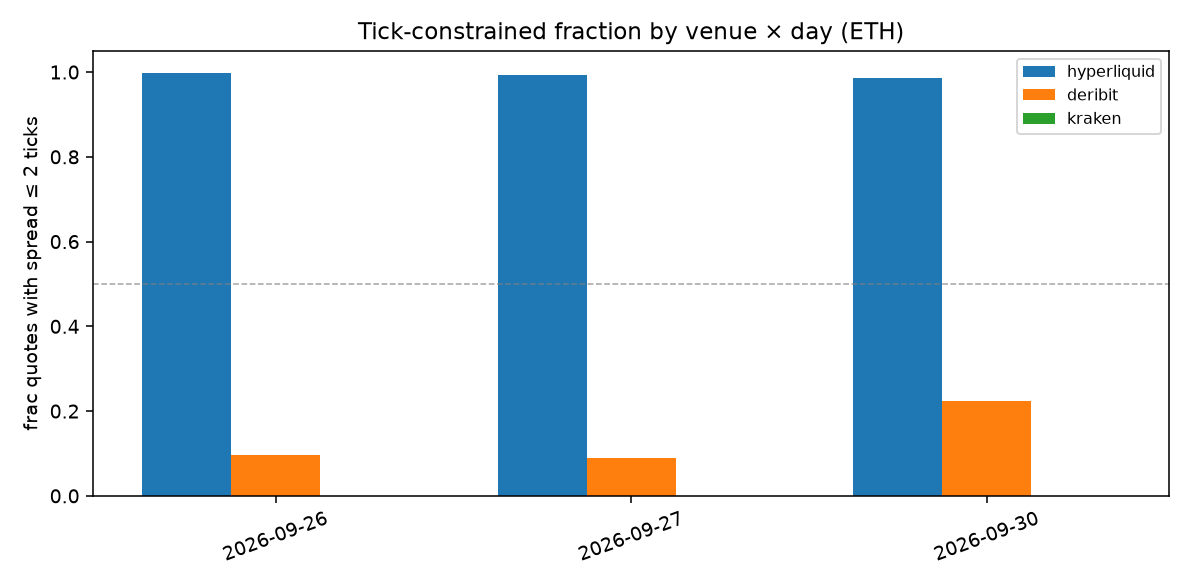

### `fig_spread_ticks_hist.png`

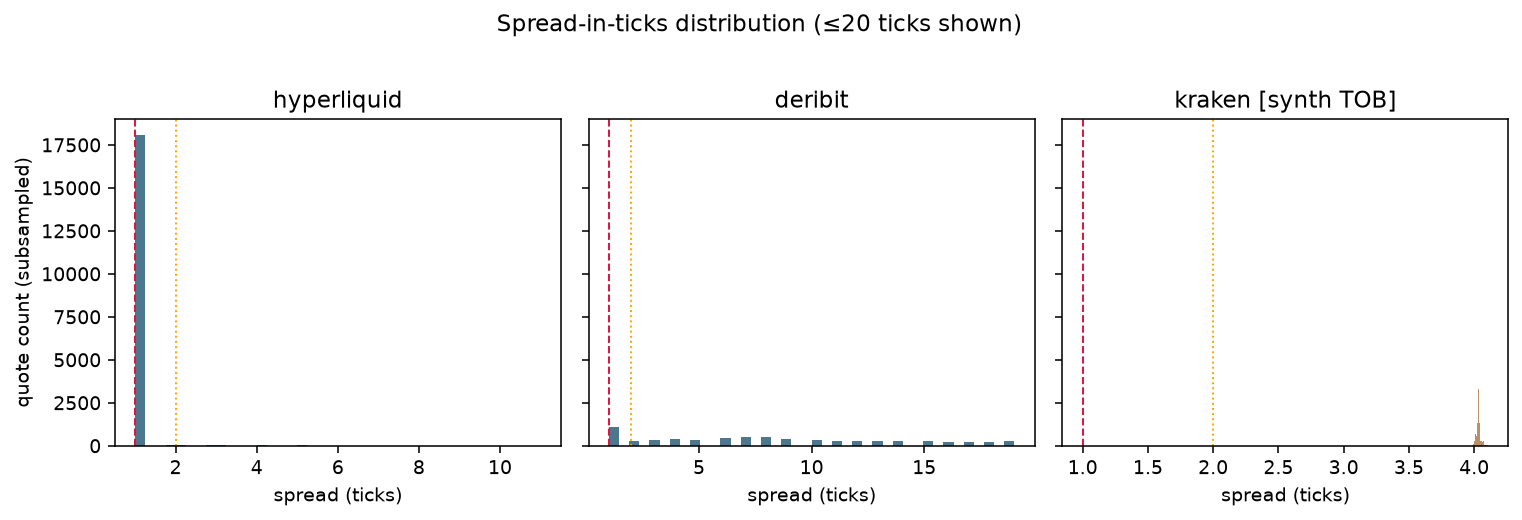

### `fig_undercut_vs_constraint.png`

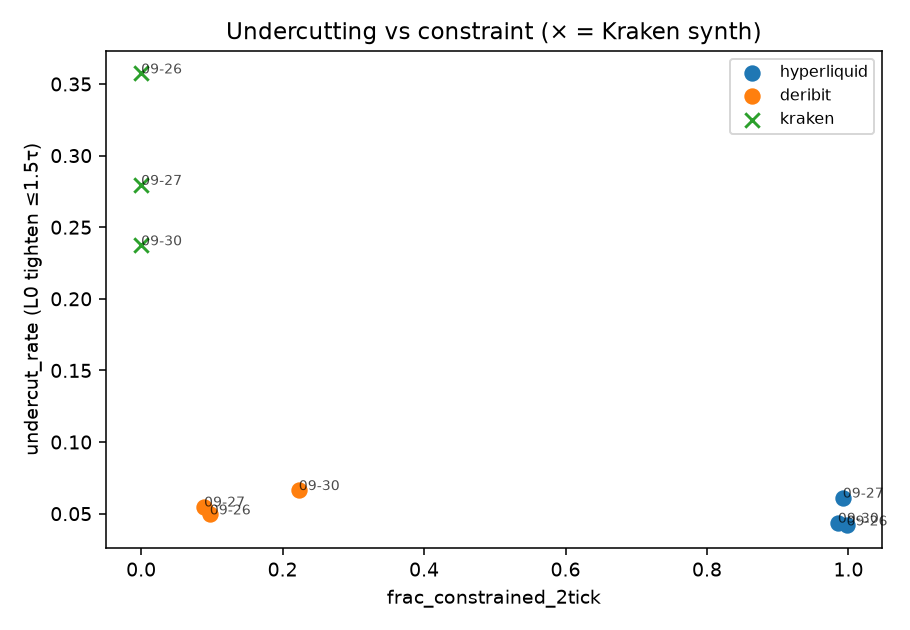

In [2]:
for name in ['fig_frac_constrained_panel.png', 'fig_spread_ticks_hist.png', 'fig_undercut_vs_constraint.png']:
    display(Markdown(f'### `{name}`'))
    display(Image(filename=str(FIGS / name)))

## Pass 2 — relax event study (OFI / undercut around flips)

Quote-level constrained→unconstrained flips mapped to 1-minute bars (HL+Deribit). Kraken synth excluded. Desk rule: *fragility_monitor* when high constraint + high undercut; *exec_throttle* only if 1s markout also worsens (>5 bps).

native flips (relax): 1012
mean ofi_corr (native): 0.2656055173121519
mean markout_1s_bps (native): 24.61971750975273


### `fig_relax_event_study.png`

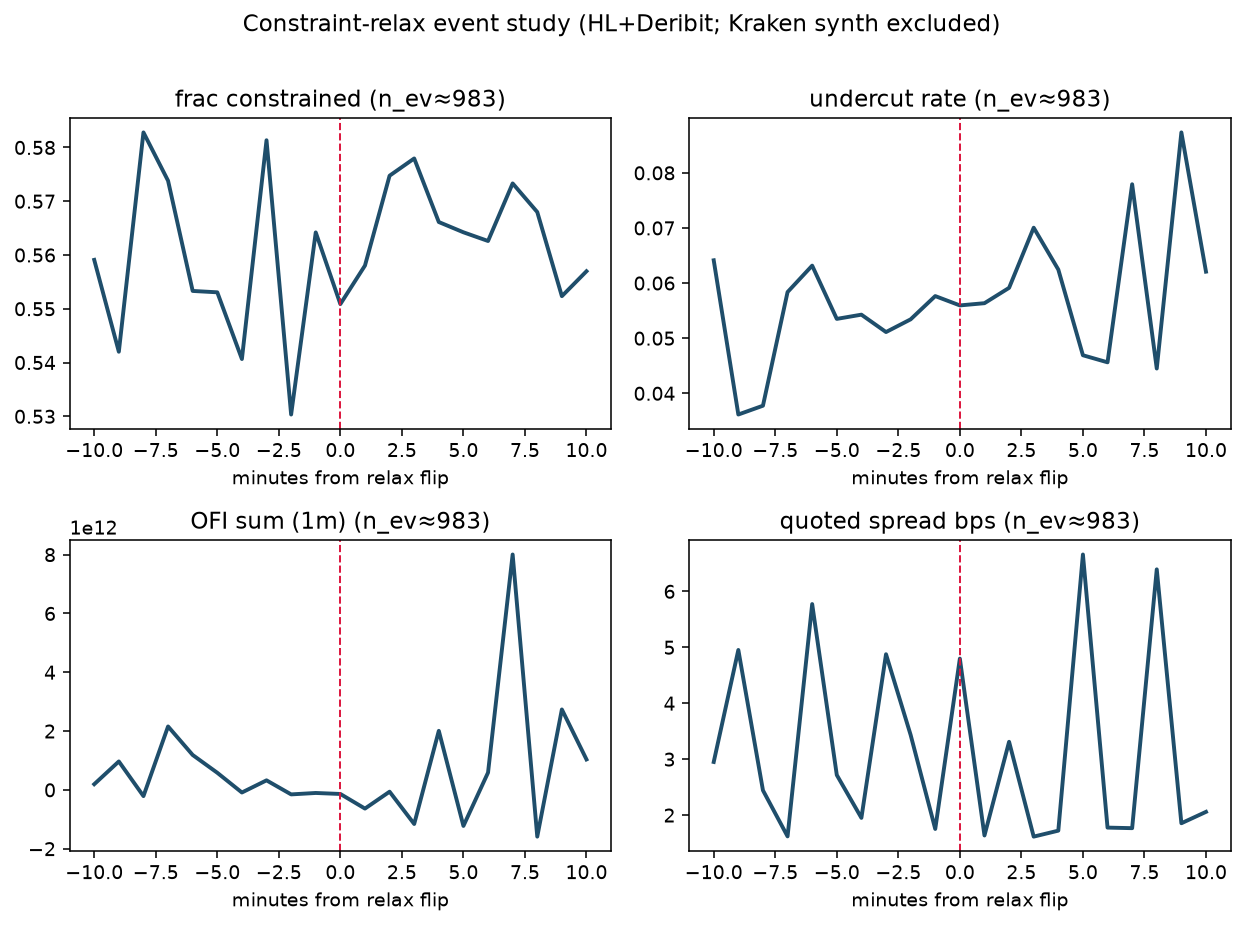

### `fig_intraday_constraint_hl.png`

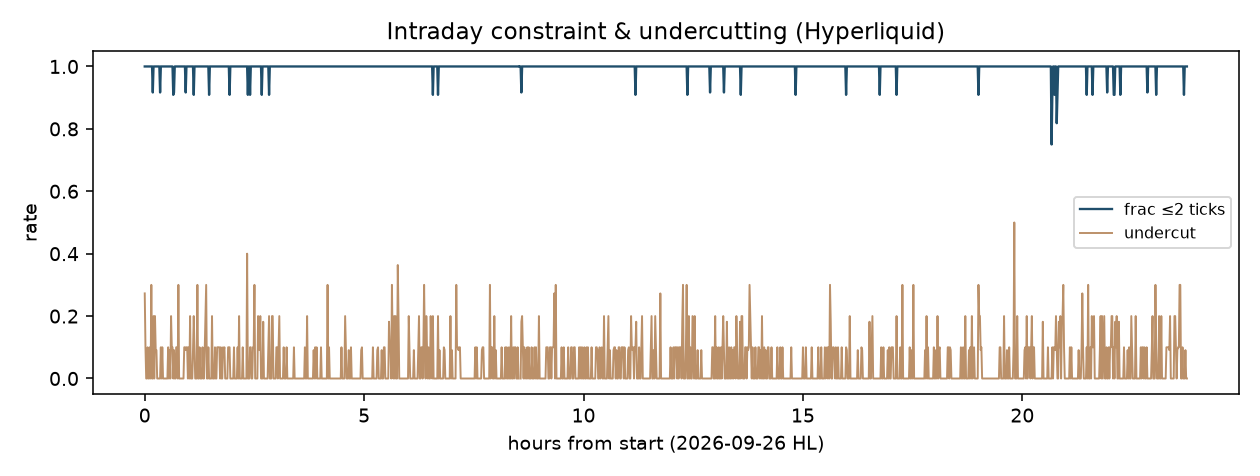

### `fig_desk_labels.png`

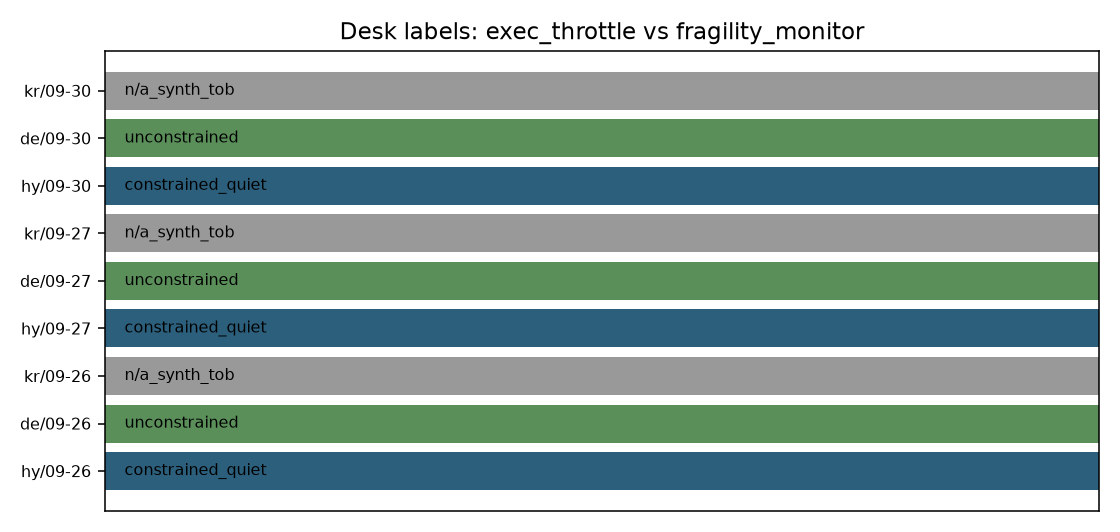

In [3]:
native = df[~df['is_synth'].fillna(False)]
print('native flips (relax):', int(native['n_flips_relax'].fillna(0).sum()))
print('mean ofi_corr (native):', float(native['ofi_corr'].mean()))
print('mean markout_1s_bps (native):', float(native['markout_1s_bps'].mean()))
for name in ['fig_relax_event_study.png', 'fig_intraday_constraint_hl.png', 'fig_desk_labels.png']:
    display(Markdown(f'### `{name}`'))
    display(Image(filename=str(FIGS / name)))

## Signal board / gate

| Candidate | Tentative | Why |
|-----------|-----------|-----|
| `exec.tick_constrained_flag` | **Hold** | Strong venue separation (HL≈1-tick vs Deribit loose) but overlaps mmip `tick.frac_one_tick`; incremental falsifier still thin |
| `exec.undercut_rate` | **Hold** | L0 tighten proxy ≠ true undercut queue; Kraken synth inflates rate |
| `info.constraint_relax_ofi` | **Hold** | Event stacks exist; OFI response not yet time-split / bootstrap stable |
| `exec.throttle_vs_fragility` | **Hold** | Labels fire `constrained_quiet` on HL (high constraint, modest undercut, mild markout) — no Promote to throttle without markout falsifier |

**Gate recommendation:** keep **Hold** on all three; widen BTC + more days before Promote. Never Promote Kraken-only constraint metrics while TOB is trade-synth.

In [4]:
# Completeness snapshot
comp = []
for r in summary['rows']:
    c = r.get('completeness') or {}
    comp.append({'venue': r['venue'], 'day': r['day'], 'complete': c.get('complete'), 'n_trades': c.get('n'), 'coverage': c.get('coverage'), 'is_synth': r.get('is_synth')})
display(pd.DataFrame(comp))

,venue,day,complete,n_trades,coverage,is_synth
0,hyperliquid,2026-09-26,True,69357,0.990822,False
1,deribit,2026-09-26,True,27440,0.998069,False
2,kraken,2026-09-26,True,34907,0.864098,True
3,hyperliquid,2026-09-27,True,51454,0.490286,False
4,deribit,2026-09-27,True,24559,0.500622,False
5,kraken,2026-09-27,True,40212,0.500851,True
6,hyperliquid,2026-09-30,True,143689,0.787380,False
7,deribit,2026-09-30,True,75784,0.789995,False
8,kraken,2026-09-30,True,84100,0.760281,True
